In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

In [4]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-2.000 – 2.000 sec
Baseline,off


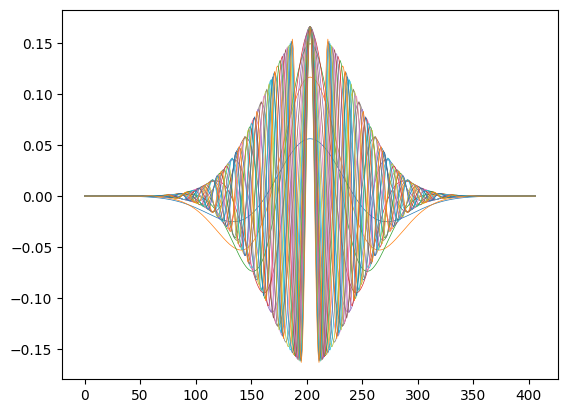

In [6]:
fmax = 16
sfreq=fmax*2
n_freqs=int(sfreq*0.7)
freqs = np.linspace(0.5, fmax, n_freqs)
n_cycles = freqs
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)
plt.show()

In [7]:
epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
#epochs_tfr.data = np.abs(epochs_tfr.data)
#epochs_tfr.crop(-0.5, 1)
#epochs_tfr.apply_baseline((-0.5, -0.1), 'logratio')
#epochs_tfr.apply_baseline((-0.5, -0.1), 'mean')
epochs_tfr.crop(0, 0.7)


epochs_tfr

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   20.4s remaining:   34.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   24.3s remaining:   14.6s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   26.1s finished


Not setting metadata


<EpochsTFR | time : [0.000000, 0.687500], freq : [0.500000, 16.000000], epochs : 4200, channels : 8, ~259.4 MB>

In [8]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [9]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

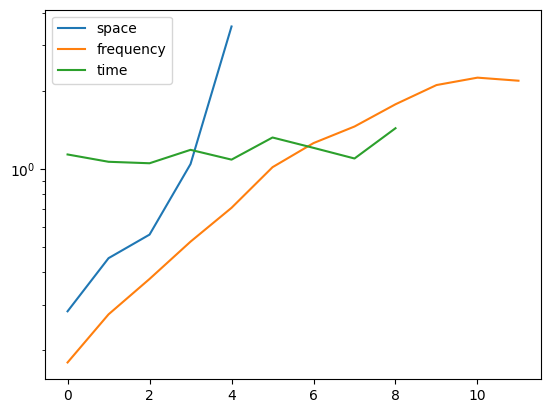

In [33]:
import tensorly.decomposition
import tensorly.tenalg

X_train = epochs_train.data
y_train = labels_train
X_test = epochs_test.data
y_test = labels_test

X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:,:]



X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,2,3), rank=(5,12,9))
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,2,3), transpose=True)
plt.semilogy(np.mean(np.abs(X_train), axis=(0,2,3)), label='space')
plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,3)), label='frequency')
plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,2)), label='time')
plt.legend()

In [34]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [37]:
hoda = HODA(max_iter=256, rank=4, tol=0, initialize ='identity', verbose=True, 
            shrinkage='oas', toeplitz=None)
hoda.fit(X_train,y_train)

[0/256]  shrinkage[0]=0.0014  shrinkage[1]=0.0052  shrinkage[2]=0.0120  step=3.1991e+00
[1/256]  shrinkage[0]=0.0019  shrinkage[1]=0.0035  shrinkage[2]=0.0019  step=2.4104e+00
[2/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0070  shrinkage[2]=0.0025  step=2.0950e+00
[3/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0049  shrinkage[2]=0.0023  step=2.0318e+00
[4/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0059  shrinkage[2]=0.0023  step=2.1827e+00
[5/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0054  shrinkage[2]=0.0033  step=2.4183e+00
[6/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0042  shrinkage[2]=0.0020  step=2.3523e+00
[7/256]  shrinkage[0]=0.0016  shrinkage[1]=0.0057  shrinkage[2]=0.0050  step=2.1330e+00
[8/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0036  shrinkage[2]=0.0022  step=1.8775e+00
[9/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0053  shrinkage[2]=0.0069  step=1.9794e+00
[10/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0034  shrinkage[2]=0.0029  step=1.9771e+00
[11/256]  shrinkage[0]=0.0015  

[93/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0042  shrinkage[2]=0.0017  step=2.3777e+00
[94/256]  shrinkage[0]=0.0016  shrinkage[1]=0.0056  shrinkage[2]=0.0033  step=2.2524e+00
[95/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0040  shrinkage[2]=0.0016  step=2.3003e+00
[96/256]  shrinkage[0]=0.0016  shrinkage[1]=0.0052  shrinkage[2]=0.0038  step=2.2960e+00
[97/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0039  shrinkage[2]=0.0016  step=2.2622e+00
[98/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0047  shrinkage[2]=0.0079  step=2.2800e+00
[99/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0032  shrinkage[2]=0.0015  step=2.2793e+00
[100/256]  shrinkage[0]=0.0014  shrinkage[1]=0.0047  shrinkage[2]=0.0124  step=2.2780e+00
[101/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0028  shrinkage[2]=0.0015  step=2.3031e+00
[102/256]  shrinkage[0]=0.0014  shrinkage[1]=0.0049  shrinkage[2]=0.0259  step=2.3843e+00
[103/256]  shrinkage[0]=0.0018  shrinkage[1]=0.0026  shrinkage[2]=0.0015  step=2.3310e+00
[104/256]  shrink

[185/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0034  shrinkage[2]=0.0027  step=1.9509e+00
[186/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0051  shrinkage[2]=0.0044  step=1.9487e+00
[187/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0034  shrinkage[2]=0.0027  step=1.9374e+00
[188/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0051  shrinkage[2]=0.0044  step=1.9336e+00
[189/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0034  shrinkage[2]=0.0026  step=1.9220e+00
[190/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0051  shrinkage[2]=0.0044  step=1.9167e+00
[191/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0035  shrinkage[2]=0.0026  step=1.9055e+00
[192/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0051  shrinkage[2]=0.0044  step=1.9935e+00
[193/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0035  shrinkage[2]=0.0026  step=1.9832e+00
[194/256]  shrinkage[0]=0.0015  shrinkage[1]=0.0051  shrinkage[2]=0.0043  step=1.9756e+00
[195/256]  shrinkage[0]=0.0017  shrinkage[1]=0.0035  shrinkage[2]=0.0026  step=1.9658e+00
[196/256] 

HODA(max_iter=256, rank=4, tol=0, verbose=True)

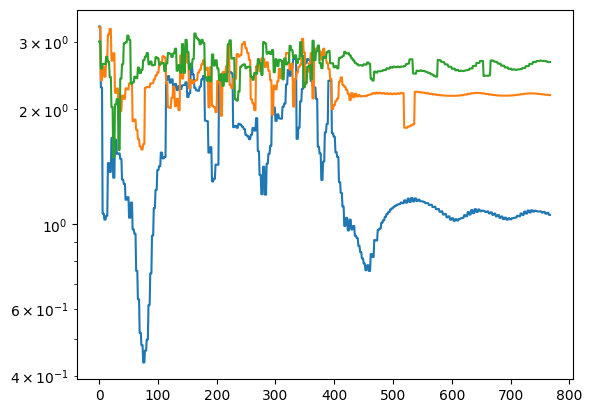

In [38]:
plt.semilogy(hoda.updates_[:,:hoda.iter_])
plt.show()

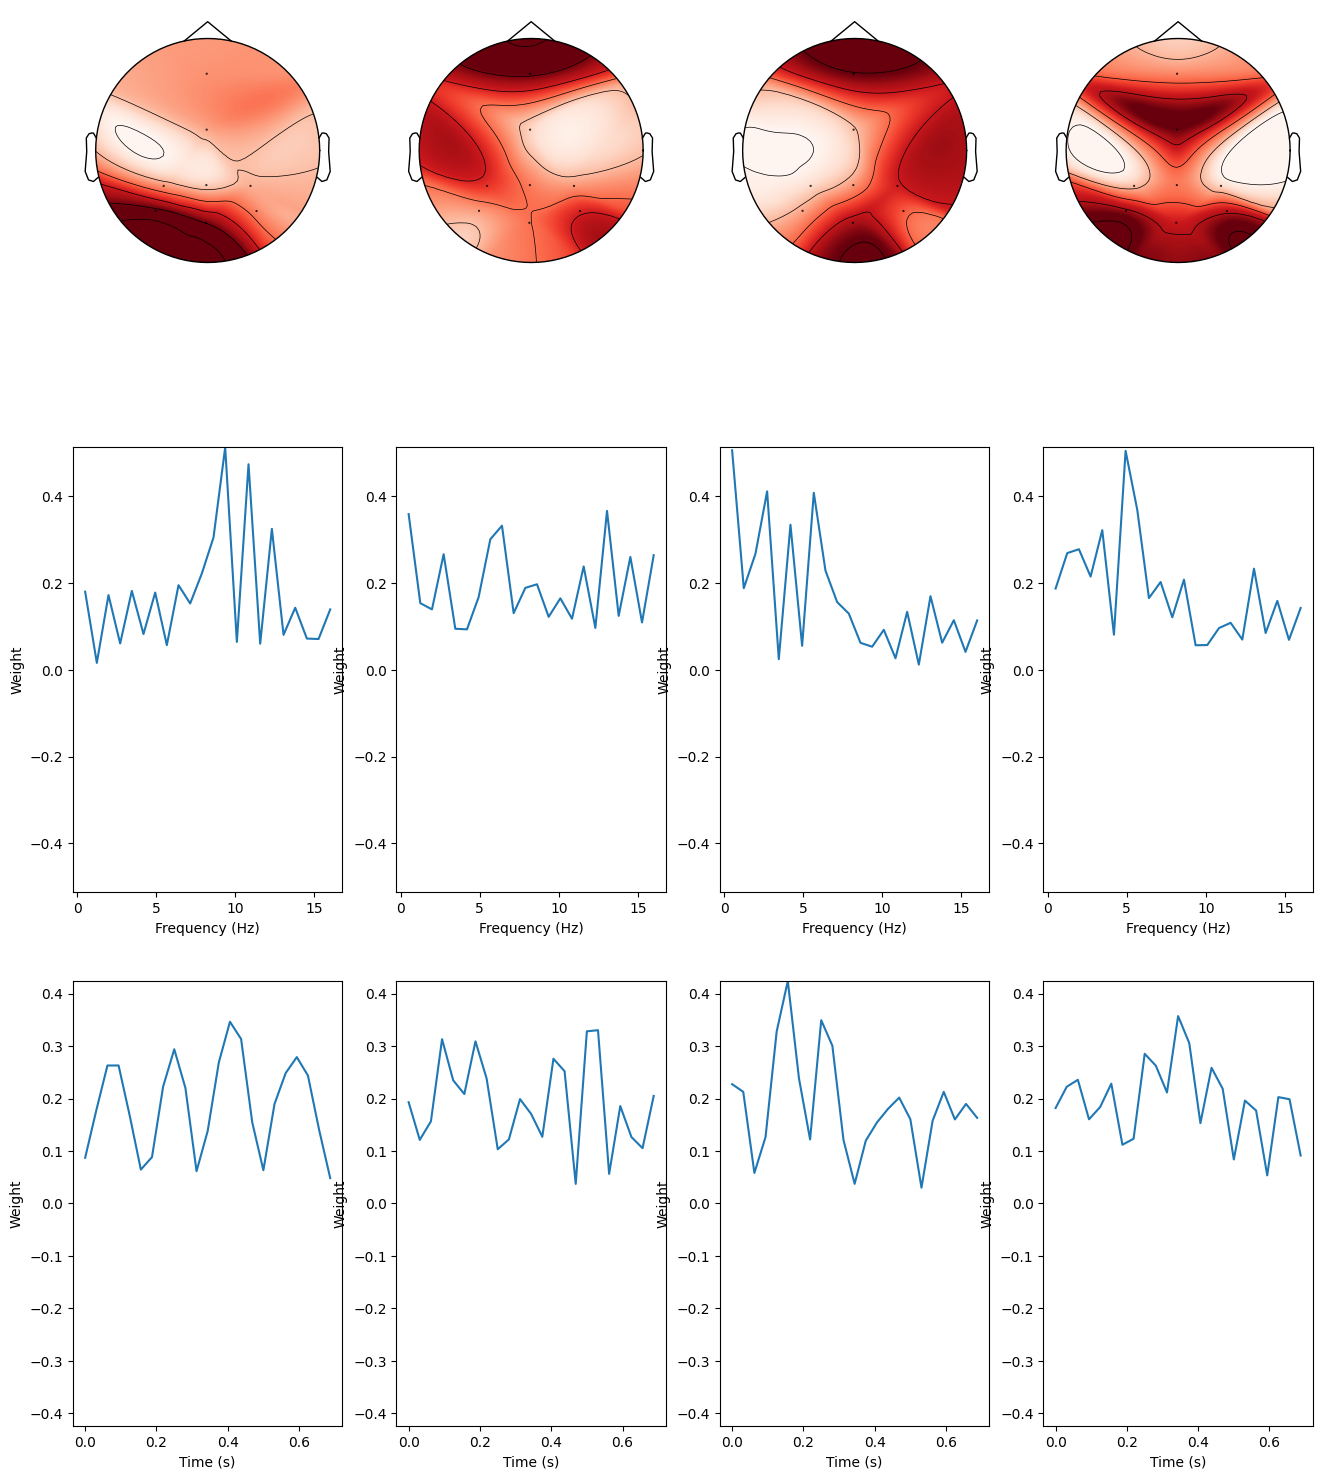

In [39]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
sp_rank = min(hoda.rank, len(epochs.ch_names))
projs = [np.abs(factors[k] @ p) for k, p in enumerate(hoda.projs_)]
for i in range(sp_rank):
    w = projs[0][:,i]
    if sp_rank >1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(projs[2]))
for i in range(hoda.rank):
    w = projs[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

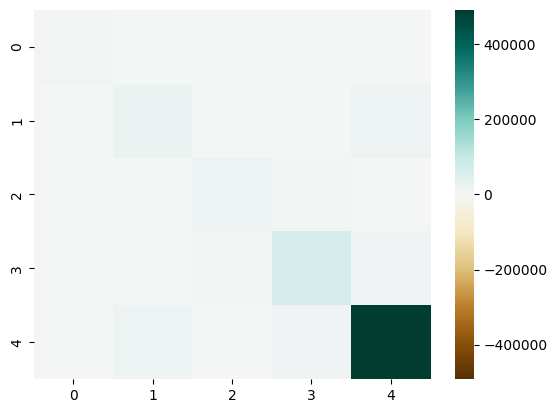

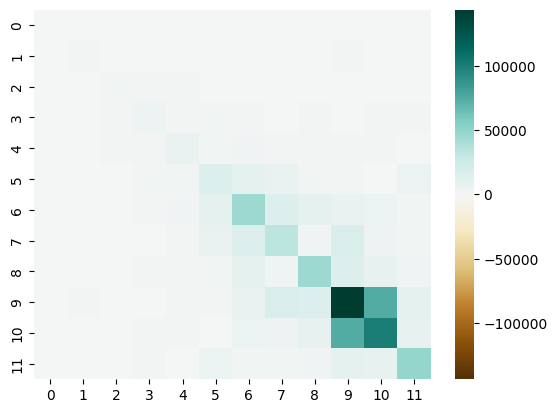

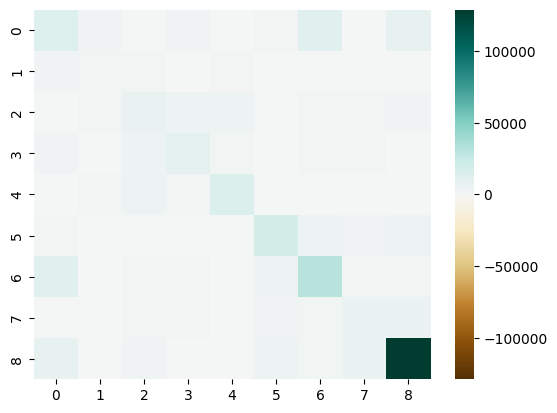

In [40]:
for k in range(3):
    cov = np.abs(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

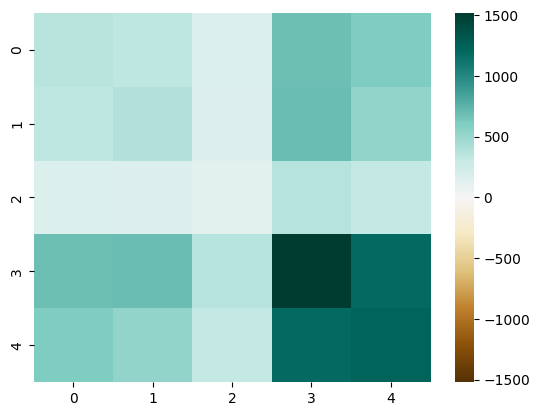

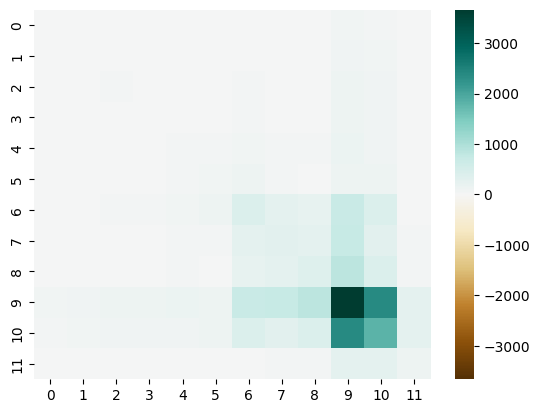

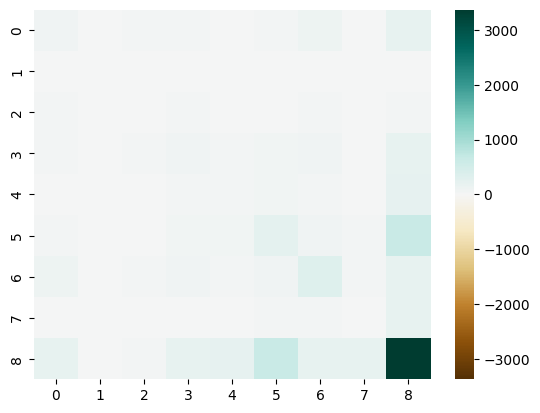

In [41]:
for k in range(3):
    cov = np.abs(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

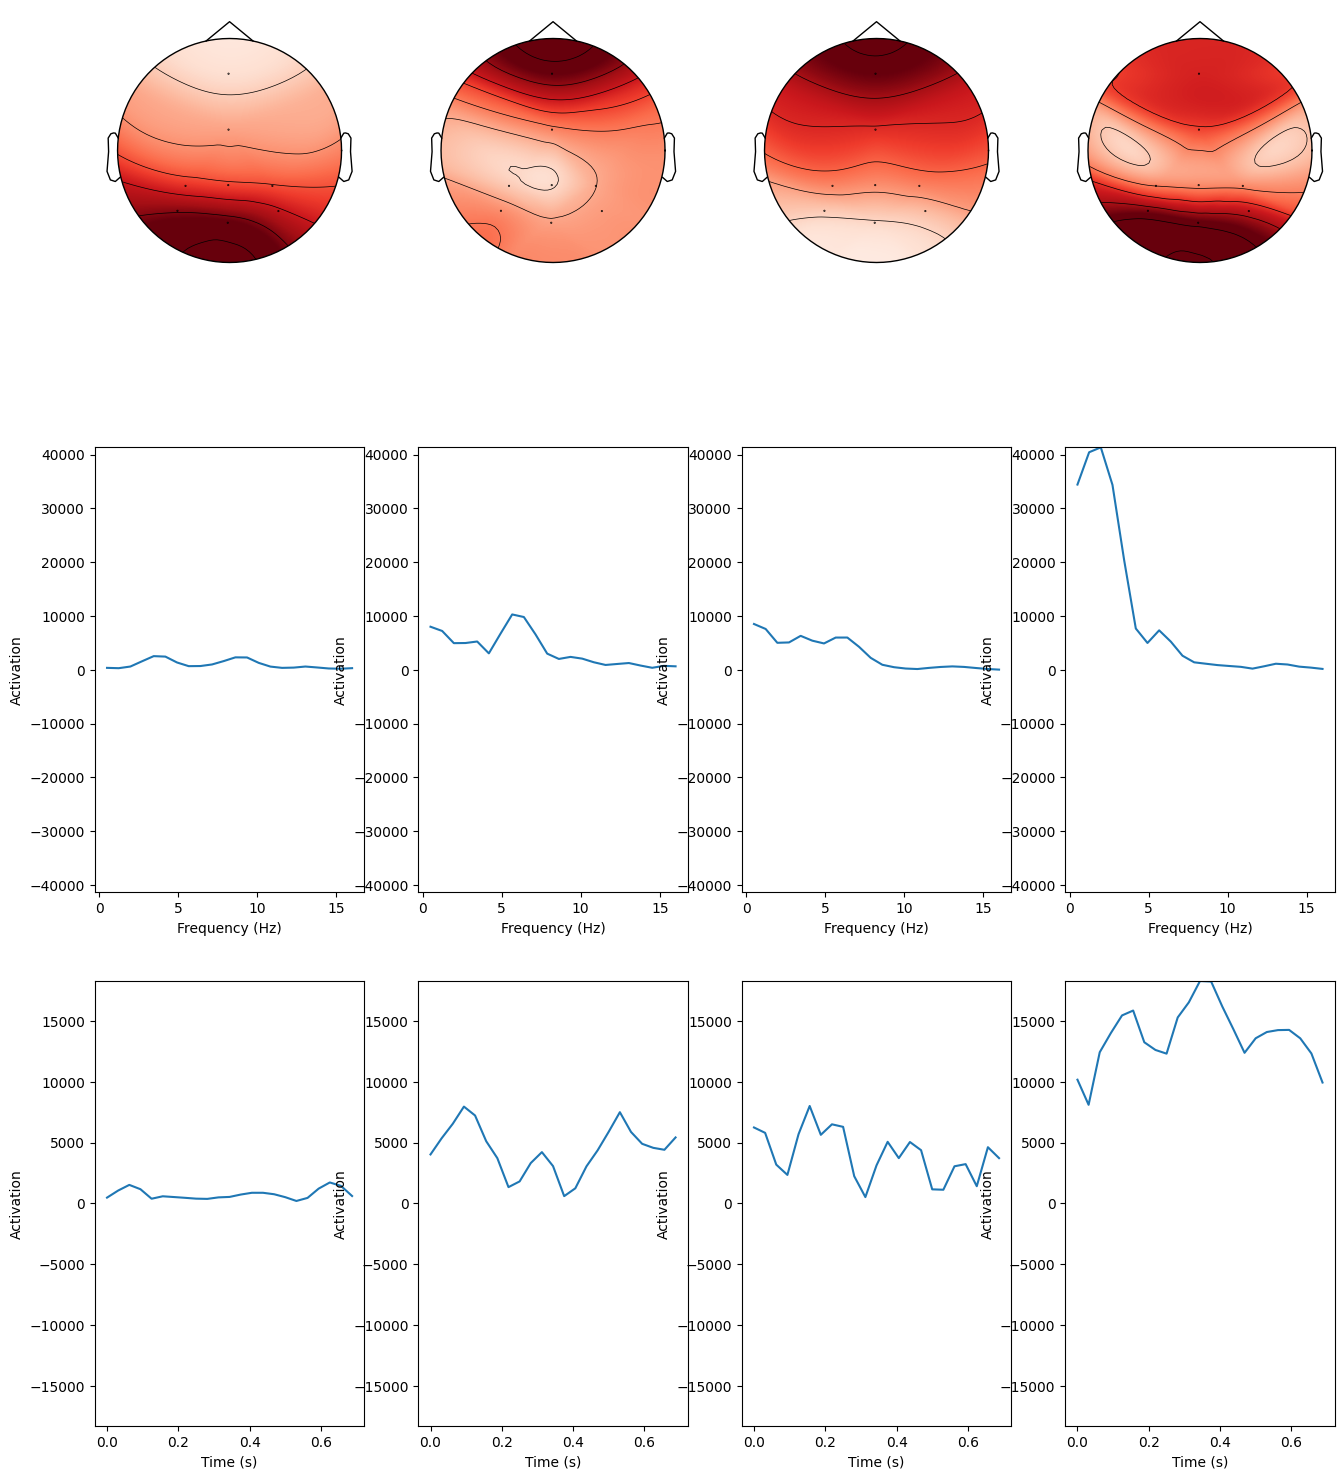

In [42]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
aps = [np.abs(factors[k] @ hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(sp_rank):
    w = aps[0][:,i]
    if sp_rank > 1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Activation')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank):
    w = aps[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Activation')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

In [43]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)

fu = FeatureUnion([("real",FunctionTransformer(np.real)),
                   ("imag",FunctionTransformer(np.imag))])

Xt_train = fu.fit_transform(Xt_train)
Xt_test = fu.transform(Xt_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

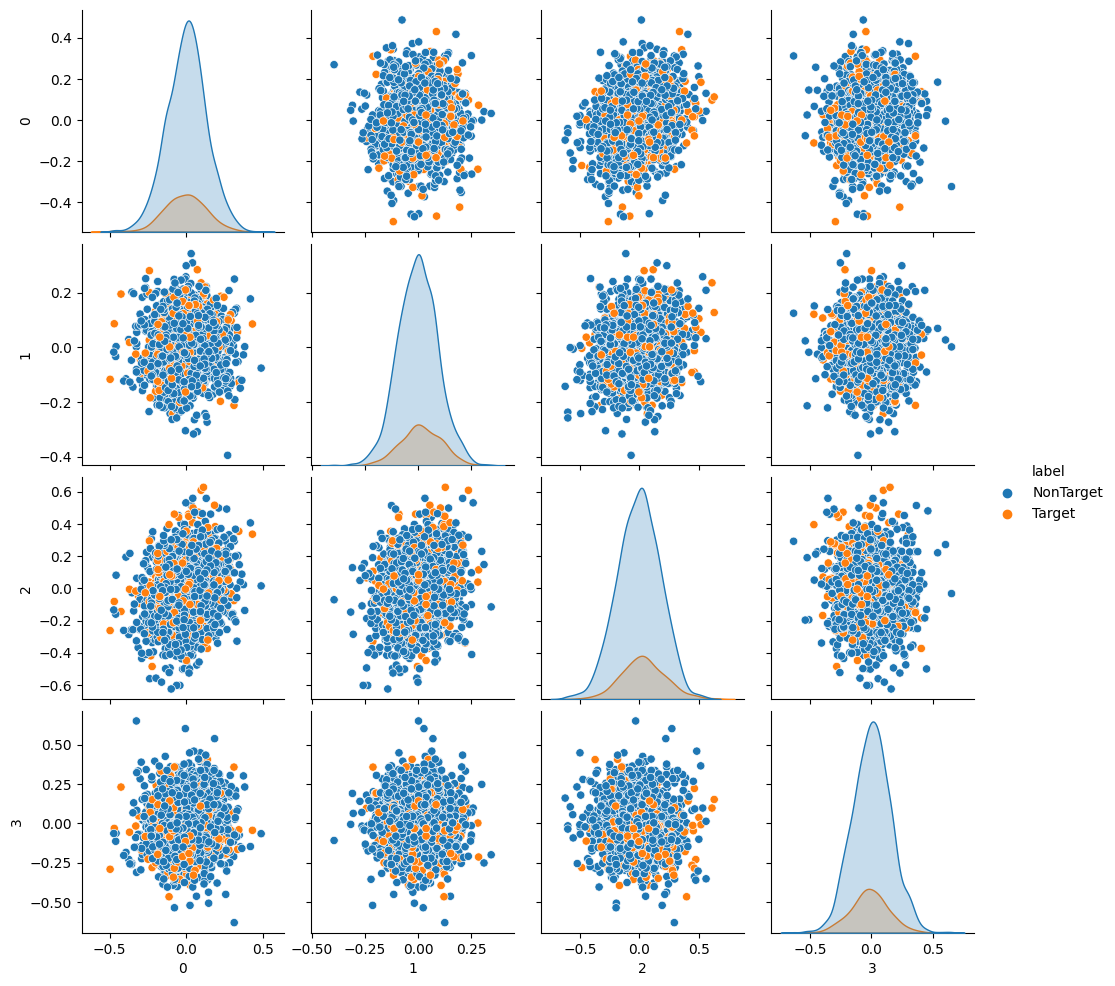

In [45]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')
plt.show()

In [46]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8758710204081632

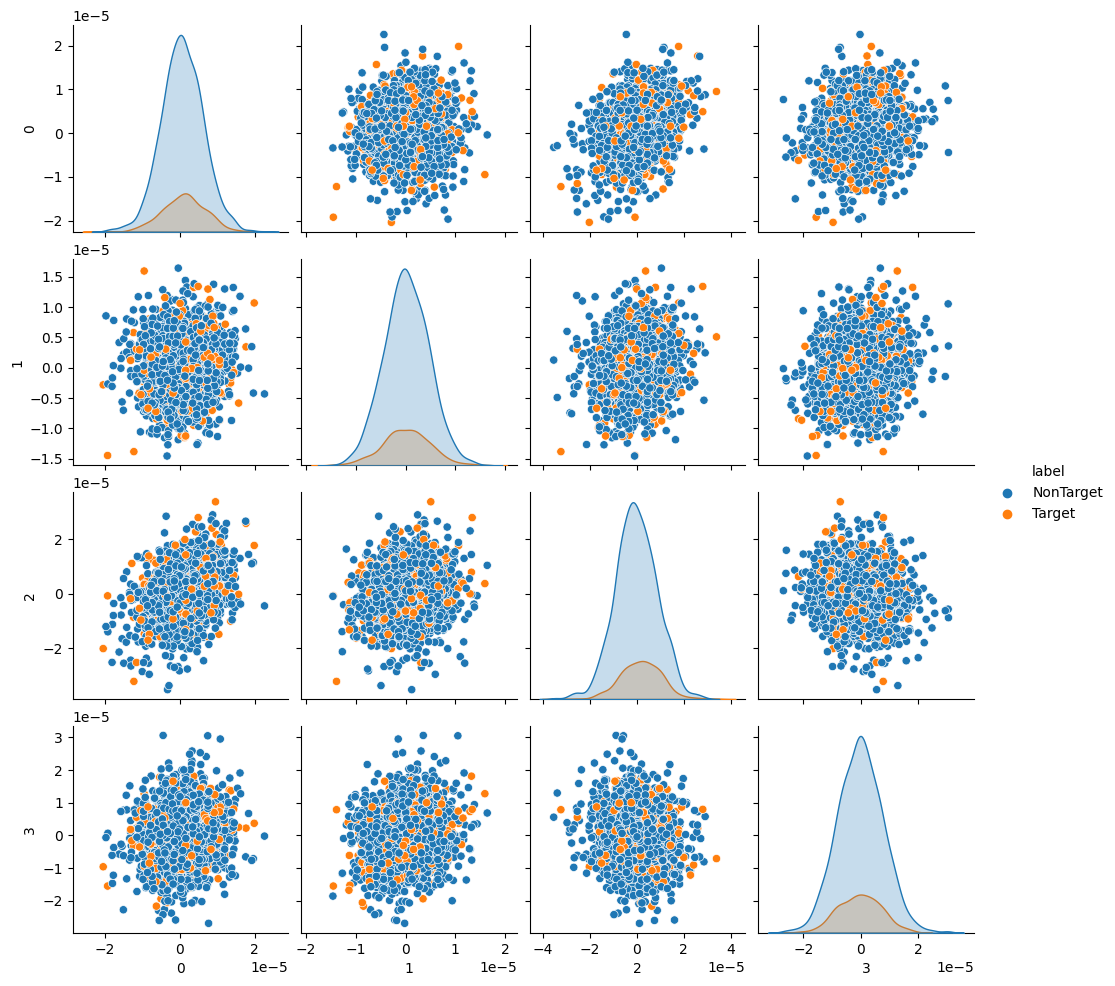

In [47]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')
plt.show()

In [48]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.7803363265306122